In [ ]:
#User will give the image,add the image  ,want to convert into 5-7 filter 
import cv2

img = cv2.imread("D:\emoji")

if img is None:
    print("Image not found!")
    exit()

while True:

    print("""
    ===== IMAGE FILTER MENU =====
    1. Grayscale
    2. Blur
    3. Edge Detection
    4. Negative
    5. Black & White
    6. Cartoon Effect
    7. Exit
    """)

    choice = input("Enter your choice: ")

    if choice == "1":

        result = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    elif choice == "2":

        result = cv2.GaussianBlur(img, (15,15), 0)

    elif choice == "3":

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        result = cv2.Canny(gray, 100, 200)

    elif choice == "4":

        result = cv2.bitwise_not(img)

    elif choice == "5":

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        _, result = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

    elif choice == "6":

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        blur = cv2.medianBlur(gray, 5)

        edges = cv2.adaptiveThreshold(
            blur,
            255,
            cv2.ADAPTIVE_THRESH_MEAN_C,
            cv2.THRESH_BINARY,
            9,
            9
        )

        color = cv2.bilateralFilter(img, 9, 250, 250)

        result = cv2.bitwise_and(color, color, mask=edges)

    elif choice == "7":

        print("Thank You!")
        break

    else:

        print("Invalid Choice")
        continue

    cv2.imshow("Original Image", img)
    cv2.imshow("Filtered Image", result)

    cv2.waitKey(0)
    cv2.destroyAllWindows()


    ===== IMAGE FILTER MENU =====
    1. Grayscale
    2. Blur
    3. Edge Detection
    4. Negative
    5. Black & White
    6. Cartoon Effect
    7. Exit
    


Enter your choice:  3



    ===== IMAGE FILTER MENU =====
    1. Grayscale
    2. Blur
    3. Edge Detection
    4. Negative
    5. Black & White
    6. Cartoon Effect
    7. Exit
    


In [3]:
#WEBCOM VIDEO IN MULTIPLE BOXES OR PANELS SIDE BY SIDE 

import cv2
import numpy as np

cap = cv2.VideoCapture(0)

while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame = cv2.resize(frame, (320, 240))

    # Filter 1 - Original
    original = frame.copy()

    # Filter 2 - Grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

    # Filter 3 - Edge Detection
    edges = cv2.Canny(frame, 100, 200)
    edges = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)

    # Filter 4 - Negative
    negative = cv2.bitwise_not(frame)

    # Top Row
    top = np.hstack((original, gray))

    # Bottom Row
    bottom = np.hstack((edges, negative))

    # Final Grid
    final = np.vstack((top, bottom))

    cv2.imshow("Multi Filter Camera", final)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

In [ ]:
#DETECT FINGERS AND HANDS 

Enter Width:  400
Enter Height:  300


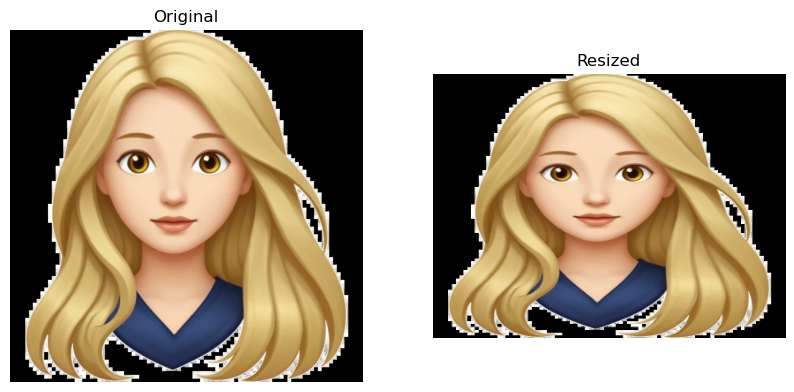

In [4]:
#CHANGING THE DIMENSION OF THE IMAGE AS PER THE USER WANTS 
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("D:\emoji")

width = int(input("Enter Width: "))
height = int(input("Enter Height: "))

resized = cv2.resize(img, (width, height))

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
resized_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(resized_rgb)
plt.title("Resized")
plt.axis("off")

plt.show()

In [ ]:
#TO DETECT THE FINGERS AND HANDLES

In [3]:
#VIDEO MENU
import cv2

 
face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

eye_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_eye.xml"
)

smile_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_smile.xml"
)

print("""
========================================
         AI CAMERA SYSTEM
========================================
1. Face Detection
2. Eye Detection
3. Smile Detection
4. Face Blur
5. Face Counter
6. Grayscale Camera
7. Edge Detection
8. Activity Counter
9. Exit
========================================
""")

choice = int(input("Enter Your Choice: "))

if choice == 9:
    print("Goodbye!")
    exit()

cap = cv2.VideoCapture(0)

# For Activity Counter
prev_gray = None
activity_count = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # 1. Face Detection
  
    if choice == 1:

        faces = face_detector.detectMultiScale(gray, 1.1, 5)

        for (x, y, w, h) in faces:
            cv2.rectangle(
                frame,
                (x, y),
                (x + w, y + h),
                (0, 255, 0),
                2
            )

        cv2.imshow("Face Detection", frame)

    
    # 2. Eye Detection
 
    elif choice == 2:

        faces = face_detector.detectMultiScale(gray, 1.1, 5)

        for (x, y, w, h) in faces:

            cv2.rectangle(
                frame,
                (x, y),
                (x + w, y + h),
                (0, 255, 0),
                2
            )

            face_gray = gray[y:y+h, x:x+w]
            face_color = frame[y:y+h, x:x+w]

            eyes = eye_detector.detectMultiScale(
                face_gray,
                scaleFactor=1.1,
                minNeighbors=8
            )

            for (ex, ey, ew, eh) in eyes:

                cv2.rectangle(
                    face_color,
                    (ex, ey),
                    (ex + ew, ey + eh),
                    (255, 0, 0),
                    2
                )

        cv2.imshow("Eye Detection", frame)

    
    
    # 3. Smile Detection
 
    elif choice == 3:

        smiles = smile_detector.detectMultiScale(
            gray,
            scaleFactor=1.8,
            minNeighbors=20
        )

        for (x, y, w, h) in smiles:

            cv2.rectangle(
                frame,
                (x, y),
                (x + w, y + h),
                (0, 255, 255),
                2
            )

        cv2.imshow("Smile Detection", frame)

   
    # 4. Face Blur
   
    elif choice == 4:

        faces = face_detector.detectMultiScale(gray, 1.1, 5)

        for (x, y, w, h) in faces:

            roi = frame[y:y+h, x:x+w]

            blur = cv2.GaussianBlur(
                roi,
                (99, 99),
                30
            )

            frame[y:y+h, x:x+w] = blur

        cv2.imshow("Face Blur", frame)

   
    # 5. Face Counter
   
    elif choice == 5:

        faces = face_detector.detectMultiScale(gray, 1.1, 5)

        count = len(faces)

        for (x, y, w, h) in faces:

            cv2.rectangle(
                frame,
                (x, y),
                (x + w, y + h),
                (0, 255, 0),
                2
            )

        cv2.putText(
            frame,
            f"Faces: {count}",
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 255, 0),
            2
        )

        cv2.imshow("Face Counter", frame)

  
    # 6. Grayscale Camera
  
    elif choice == 6:

        cv2.imshow("Grayscale Camera", gray)

   
    # 7. Edge Detection
   
    elif choice == 7:

        edges = cv2.Canny(gray, 100, 200)

        cv2.imshow("Edge Detection", edges)

   
    # 8. Activity Counter
  
    elif choice == 8:

        if prev_gray is None:
            prev_gray = gray
            continue

        frame_diff = cv2.absdiff(prev_gray, gray)

        _, thresh = cv2.threshold(
            frame_diff,
            25,
            255,
            cv2.THRESH_BINARY
        )

        contours, _ = cv2.findContours(
            thresh,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        movement = False

        for contour in contours:

            if cv2.contourArea(contour) > 1500:

                x, y, w, h = cv2.boundingRect(contour)

                cv2.rectangle(
                    frame,
                    (x, y),
                    (x + w, y + h),
                    (0, 0, 255),
                    2
                )

                movement = True

        if movement:
            activity_count += 1

        cv2.putText(
            frame,
            f"Activities: {activity_count}",
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 255, 0),
            2
        )

        prev_gray = gray.copy()

        cv2.imshow("Activity Counter", frame)

    # Exit Key
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


         AI CAMERA SYSTEM
1. Face Detection
2. Eye Detection
3. Smile Detection
4. Face Blur
5. Face Counter
6. Grayscale Camera
7. Edge Detection
8. Activity Counter
9. Exit



Enter Your Choice:  2



     IMAGE TRANSFORMATION MENU

1. Original Image
2. Crop Image
3. Resize Image
4. Grayscale Image
5. Black Canvas
6. Blue Canvas
7. Green Canvas
8. Red Canvas
9. Negative Image
10. Blur Image
11. Edge Detection
12. Black & White
13. Exit




Enter Choice:  1


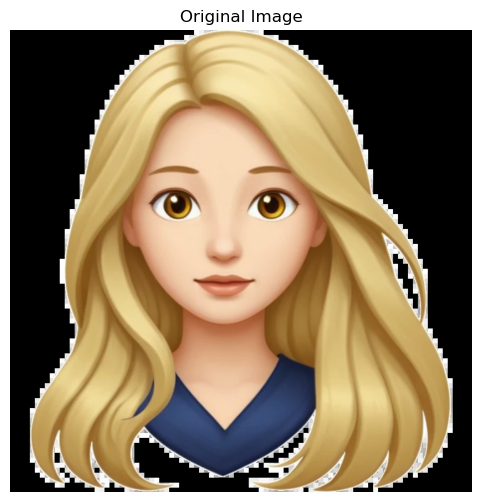


     IMAGE TRANSFORMATION MENU

1. Original Image
2. Crop Image
3. Resize Image
4. Grayscale Image
5. Black Canvas
6. Blue Canvas
7. Green Canvas
8. Red Canvas
9. Negative Image
10. Blur Image
11. Edge Detection
12. Black & White
13. Exit




Enter Choice:  2
Enter x:  45
Enter y:  70
Enter width:  80
Enter height:  90


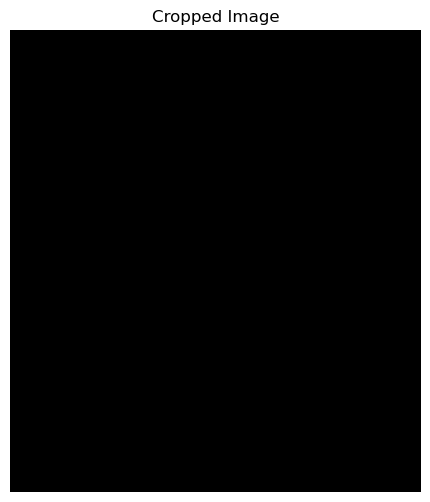


     IMAGE TRANSFORMATION MENU

1. Original Image
2. Crop Image
3. Resize Image
4. Grayscale Image
5. Black Canvas
6. Blue Canvas
7. Green Canvas
8. Red Canvas
9. Negative Image
10. Blur Image
11. Edge Detection
12. Black & White
13. Exit




Enter Choice:  8


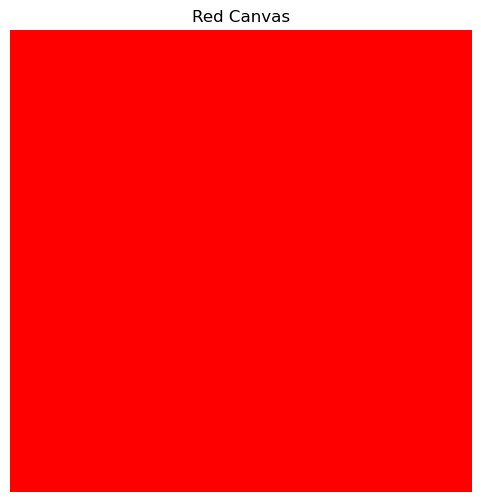


     IMAGE TRANSFORMATION MENU

1. Original Image
2. Crop Image
3. Resize Image
4. Grayscale Image
5. Black Canvas
6. Blue Canvas
7. Green Canvas
8. Red Canvas
9. Negative Image
10. Blur Image
11. Edge Detection
12. Black & White
13. Exit




In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


# LOAD IMAGE


img = cv2.imread("D:\emoji")

if img is None:
    print("Image Not Found!")
    exit()


# DISPLAY FUNCTION


def show_image(image, title):

    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6,6))
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()


# MENU


while True:

    print("""
====================================
     IMAGE TRANSFORMATION MENU
====================================

1. Original Image
2. Crop Image
3. Resize Image
4. Grayscale Image
5. Black Canvas
6. Blue Canvas
7. Green Canvas
8. Red Canvas
9. Negative Image
10. Blur Image
11. Edge Detection
12. Black & White
13. Exit

====================================
""")

    choice = input("Enter Choice: ")

    # ORIGINAL IMAGE
  
    if choice == "1":

        show_image(img, "Original Image")

   
    # CROP IMAGE
 

    elif choice == "2":

        x = int(input("Enter x: "))
        y = int(input("Enter y: "))

        w = int(input("Enter width: "))
        h = int(input("Enter height: "))

        cropped = img[y:y+h, x:x+w]

        show_image(cropped, "Cropped Image")
    # RESIZE IMAGE
  

    elif choice == "3":

        width = int(input("Enter Width: "))
        height = int(input("Enter Height: "))

        resized = cv2.resize(
            img,
            (width, height)
        )

        show_image(resized, "Resized Image")

    
    # GRAYSCALE
   

    elif choice == "4":

        gray = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2GRAY
        )

        show_image(gray, "Grayscale Image")

   
    # BLACK CANVAS
  

    elif choice == "5":

        black = np.zeros(
            (400,400,3),
            dtype=np.uint8
        )

        show_image(black, "Black Canvas")

    
    # BLUE CANVAS
   

    elif choice == "6":

        blue = np.zeros(
            (400,400,3),
            dtype=np.uint8
        )

        blue[:] = (255,0,0)

        show_image(blue, "Blue Canvas")

    
    # GREEN CANVAS
   
    elif choice == "7":

        green = np.zeros(
            (400,400,3),
            dtype=np.uint8
        )

        green[:] = (0,255,0)

        show_image(green, "Green Canvas")

   
    # RED CANVAS
    
    elif choice == "8":

        red = np.zeros(
            (400,400,3),
            dtype=np.uint8
        )

        red[:] = (0,0,255)

        show_image(red, "Red Canvas")


    # NEGATIVE IMAGE
  
    elif choice == "9":

        negative = cv2.bitwise_not(img)

        show_image(
            negative,
            "Negative Image"
        )

   
    # BLUR IMAGE
   
    elif choice == "10":

        blur = cv2.GaussianBlur(
            img,
            (15,15),
            0
        )

        show_image(
            blur,
            "Blur Image"
        )

    
    # EDGE DETECTION
  

    elif choice == "11":

        gray = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2GRAY
        )

        edges = cv2.Canny(
            gray,
            100,
            200
        )

        show_image(
            edges,
            "Edge Detection"
        )

    # BLACK & WHITE
   

    elif choice == "12":

        gray = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2GRAY
        )

        _, bw = cv2.threshold(
            gray,
            127,
            255,
            cv2.THRESH_BINARY
        )

        show_image(
            bw,
            "Black & White"
        )

    elif choice == "13":

        print("Thank You!")
        break

    else:

        print("Invalid Choice")